# AI Coding Interview: End-to-End Mini Task

**Task**: Given a dataset of customer features, predict whether they will churn (binary classification).

**What interviewers look for**:
1. ✅ Clean data handling
2. ✅ Reasonable model choice with justification
3. ✅ Correct loss function & evaluation metrics
4. ✅ Clean, readable code
5. ✅ Sensible explanations

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f'Using device: {device}')

Using device: mps


## Step 1: Load and Explore Data

Always start by understanding your data before modeling.

In [2]:
# Simulate a customer churn dataset
# In a real interview, you'd load from CSV: pd.read_csv('data.csv')

n_samples = 2000
n_features = 10

# Generate synthetic features (e.g., age, tenure, monthly_charges, etc.)
X = np.random.randn(n_samples, n_features)

# Create target with some pattern (not pure random - makes it learnable)
# Churn more likely if: high feature[0], low feature[1], high feature[2]
logits = 0.8 * X[:, 0] - 0.6 * X[:, 1] + 0.5 * X[:, 2] + 0.3 * np.random.randn(n_samples)
probs = 1 / (1 + np.exp(-logits))
y = (probs > 0.5).astype(np.float32)

print(f"Dataset shape: {X.shape}")
print(f"Target distribution: {np.bincount(y.astype(int))} (0: stay, 1: churn)")
print(f"Class balance: {y.mean():.2%} churn rate")

Dataset shape: (2000, 10)
Target distribution: [1010  990] (0: stay, 1: churn)
Class balance: 49.50% churn rate


## Step 2: Data Preprocessing

Key steps:
- Train/test split (BEFORE any preprocessing to avoid data leakage)
- Feature scaling (important for neural networks)
- Handle missing values (if any)

In [7]:
# 1. Check for missing values (critical in real interviews!)
print(f"Missing values: {np.isnan(X).sum()}")

# 2. Train/Validation/Test split
# Use stratify to maintain class balance in splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# 3. Feature scaling - fit on train only to prevent data leakage!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit_transform on train
X_val = scaler.transform(X_val)          # transform only on val
X_test = scaler.transform(X_test)        # transform only on test

print(f"After scaling - Train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")

Missing values: 0
Train: 1360, Val: 240, Test: 400
After scaling - Train mean: -0.0000, std: 1.0000


In [8]:
# 4. Convert to PyTorch tensors and create DataLoaders
def create_dataloader(X, y, batch_size=32, shuffle=True):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N,) -> (N, 1)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

batch_size = 32
train_loader = create_dataloader(X_train, y_train, batch_size, shuffle=True)
val_loader = create_dataloader(X_val, y_val, batch_size, shuffle=False)
test_loader = create_dataloader(X_test, y_test, batch_size, shuffle=False)

print(f"Batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Batches - Train: 43, Val: 8, Test: 13


## Step 3: Model Definition

**Model choice justification** (interviewers love this!):
- Binary classification with tabular data → Simple MLP is a good baseline
- Dataset is small (~2K samples) → Don't need a huge model (avoid overfitting)
- Start simple, add complexity only if needed

In [ ]:
class ChurnClassifier(nn.Module):
    """
    Simple MLP for binary classification.
    Architecture: Input → Hidden1 → Hidden2 → Output
    """
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
            # No sigmoid here - we'll use BCEWithLogitsLoss for numerical stability
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize model and move to device
model = ChurnClassifier(input_dim=n_features, hidden_dim=64, dropout=0.3).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model device: {next(model.parameters()).device}")

ChurnClassifier(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2,817


## Step 4: Loss Function & Optimizer

**Loss choice justification**:
- Binary classification → Binary Cross Entropy (BCE)
- Using `BCEWithLogitsLoss` instead of `BCELoss` for numerical stability
  (combines sigmoid + BCE in one step, more stable gradients)

In [13]:
# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer - Adam is a safe default choice
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# Learning rate scheduler (optional but shows good practice)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

## Step 5: Training Loop

Key practices:
- Track both train and validation loss
- Use validation for early stopping / model selection
- Never look at test set during training!

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
    return total_loss / len(dataloader.dataset)

def evaluate(model, dataloader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * len(X_batch)
            
            # Convert logits to predictions
            preds = (torch.sigmoid(outputs) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

In [ ]:
# Training configuration
num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0
early_stop_patience = 10

# Track metrics for plotting
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # Update learning rate scheduler
    scheduler.step(val_loss)
    
    # Track history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")
    
    # Early stopping
    if patience_counter >= early_stop_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)
print("-" * 60)
print(f"Training complete! Best val loss: {best_val_loss:.4f}")

Starting training...
------------------------------------------------------------
Epoch   5/50 | Train Loss: 0.2639 | Val Loss: 0.2081 | Val Acc: 0.9125
Epoch  10/50 | Train Loss: 0.2224 | Val Loss: 0.1991 | Val Acc: 0.9000
Epoch  15/50 | Train Loss: 0.2082 | Val Loss: 0.2001 | Val Acc: 0.9042
Epoch  20/50 | Train Loss: 0.1935 | Val Loss: 0.2008 | Val Acc: 0.8958
Epoch  25/50 | Train Loss: 0.1982 | Val Loss: 0.1988 | Val Acc: 0.9083

Early stopping at epoch 28
------------------------------------------------------------
Training complete! Best val loss: 0.1964


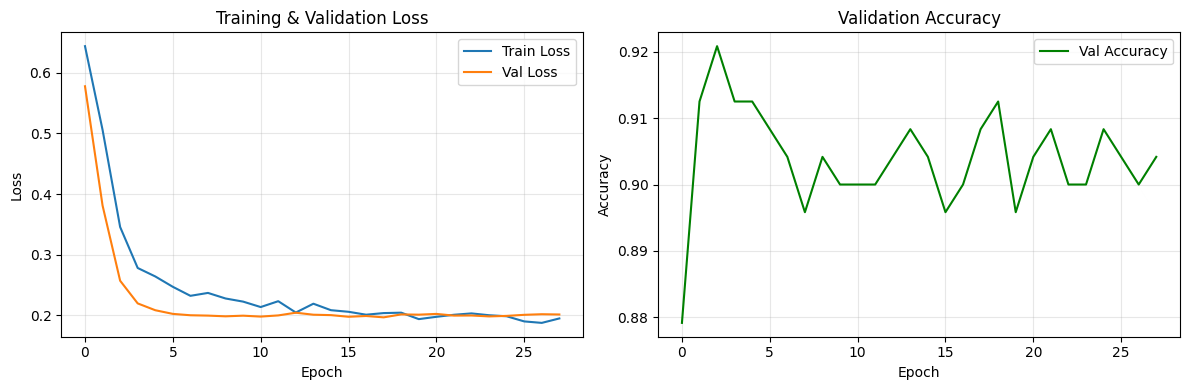

In [20]:
# Plot training history (interviewers appreciate visualizations!)
def loss_and_acc_plot(hitstory):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history['val_acc'], label='Val Accuracy', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

loss_and_acc_plot(history)

## Step 6: Final Evaluation on Test Set

**Important**: Only evaluate on test set ONCE at the very end!

**Metrics choice justification**:
- Accuracy: Overall correctness
- Precision: Of predicted churns, how many actually churned? (avoid false alarms)
- Recall: Of actual churns, how many did we catch? (don't miss churners)
- F1: Harmonic mean of precision & recall (balanced metric)

In [ ]:
def full_evaluation(model, dataloader, device):
    """Comprehensive evaluation with multiple metrics."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    
    return all_labels, all_preds, np.array(all_probs).flatten()

# Final test evaluation
y_true, y_pred, y_prob = full_evaluation(model, test_loader, device)

print("=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")
print("=" * 60)

FINAL TEST SET RESULTS
Accuracy:  0.9200
Precision: 0.9278
Recall:    0.9091
F1 Score:  0.9184


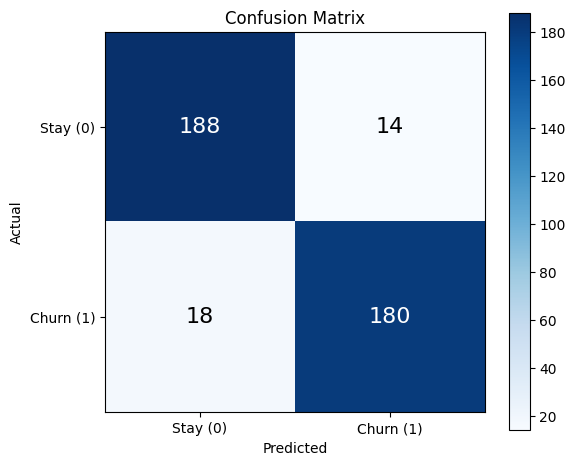


Confusion Matrix Interpretation:
  True Negatives:   188 (correctly predicted stay)
  False Positives:   14 (predicted churn, actually stay)
  False Negatives:   18 (predicted stay, actually churn)
  True Positives:   180 (correctly predicted churn)


In [22]:
# Confusion Matrix visualization
def plot_confusion_matrix(y_pred, y_ture):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap='Blues')

    # Add labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Stay (0)', 'Churn (1)'])
    ax.set_yticklabels(['Stay (0)', 'Churn (1)'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix')

    # Add values in cells
    for i in range(2):
        for j in range(2):
            text = ax.text(j, i, cm[i, j], ha='center', va='center', 
                        color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16)

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    # Interpret results
    print("\nConfusion Matrix Interpretation:")
    print(f"  True Negatives:  {cm[0,0]:4d} (correctly predicted stay)")
    print(f"  False Positives: {cm[0,1]:4d} (predicted churn, actually stay)")
    print(f"  False Negatives: {cm[1,0]:4d} (predicted stay, actually churn)")
    print(f"  True Positives:  {cm[1,1]:4d} (correctly predicted churn)")

plot_confusion_matrix(y_pred, y_true)

## Step 7: Summary & Discussion (Impress the Interviewer!)

**What we did:**
1. ✅ Explored data (checked shape, class balance, missing values)
2. ✅ Proper train/val/test split with stratification
3. ✅ Feature scaling (fit on train only - no data leakage!)
4. ✅ Simple but appropriate model (MLP for tabular data)
5. ✅ Correct loss function (BCEWithLogitsLoss for binary classification)
6. ✅ Multiple evaluation metrics (Accuracy, Precision, Recall, F1)
7. ✅ Early stopping to prevent overfitting
8. ✅ Visualizations (loss curves, confusion matrix)

**Potential improvements to mention:**
- Try other models (XGBoost, Random Forest often better for tabular)
- Hyperparameter tuning (learning rate, hidden size, dropout)
- Class imbalance handling (if unbalanced: class weights, SMOTE)
- Feature engineering (domain-specific features)
- Cross-validation for more robust evaluation

## Bonus: Quick Reference - Common Interview Gotchas

| Task Type | Loss Function | Output Activation | Metrics |
|-----------|--------------|-------------------|---------|
| Binary Classification | BCEWithLogitsLoss | Sigmoid | Accuracy, Precision, Recall, F1, AUC |
| Multi-class Classification | CrossEntropyLoss | Softmax (implicit) | Accuracy, Macro-F1, Confusion Matrix |
| Regression | MSELoss, L1Loss | None | MSE, MAE, R² |
| Multi-label Classification | BCEWithLogitsLoss | Sigmoid | Hamming Loss, Micro/Macro F1 |

**Common mistakes to avoid:**
- ❌ Scaling test data with test statistics (data leakage)
- ❌ Not using `model.eval()` during inference
- ❌ Forgetting `torch.no_grad()` during evaluation
- ❌ Only reporting accuracy on imbalanced datasets
- ❌ Not setting random seeds for reproducibility